In [1]:
import sys
print(sys.executable)

import tensorflow as tf
print("TF Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

c:\Users\Yedeedya_Injeti\anaconda3\envs\gpu_conda\python.exe
TF Version: 2.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import tensorflow as tf

print("TF Version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))
print("Num GPUs:", len(tf.config.list_physical_devices('GPU')))

TF Version: 2.10.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs: 1


In [2]:
import os
import pickle
import numpy as np
from PIL import Image
from tqdm import tqdm
import re
from collections import Counter
import random

import os
import pickle
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from nltk.translate.bleu_score import corpus_bleu
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array


## 2. DataPaths

In [3]:
IMAGE_FOLDER = r"H:\4. Projects_envs\8. Image caption CNN+LSTM\fliker8k\Images"
CAPTION_FILE = r"H:\4. Projects_envs\8. Image caption CNN+LSTM\fliker8k\captions.txt"

#  MODIFY if you want TF files in new location
OUTPUT_FILE = r"Images_features_tf.pkl"
VOCAB_FILE = r"Caption_vocab_tf.pkl"
NUMERICAL_CAPTIONS_FILE = r"Numerical_captions_tf.pkl"
RAW_CAPTION_FILE = r"Raw_captions_tf.pkl"


## 3. Load Pretrained model - (c)


In [5]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.models import Model

# Load pretrained ResNet50
cnn_model = ResNet50(weights='imagenet')

# Use global average pooling output (2048 features)
cnn_model = Model(
    inputs=cnn_model.inputs,
    outputs=cnn_model.layers[-2].output
)



#### 3.1 Image Transformation

In [ ]:
features = {}

for img_name in tqdm(os.listdir(IMAGE_FOLDER)):
    img_path = os.path.join(IMAGE_FOLDER, img_name)

    image = load_img(img_path, target_size=(224, 224))
    image = img_to_array(image)
    image = image.reshape((1, 224, 224, 3))
    image = preprocess_input(image)

    feature = cnn_model.predict(image, verbose=0)
    image_id = img_name.split('.')[0]
    features[image_id] = feature

pickle.dump(features, open(OUTPUT_FILE, "wb"))
print("Image features saved:", OUTPUT_FILE)

  0%|          | 0/8091 [00:00<?, ?it/s]

## 4 Caption data cleaning and creating vocab

#### 4.1  caption raw pk

In [11]:
# Clean Text 
mapping = {}

with open(CAPTION_FILE, 'r') as f:
    next(f)
    for line in f:
        tokens = line.strip().split(',')
        image_id = tokens[0].split('.')[0]
        caption = " ".join(tokens[1:]).lower()

        if image_id not in mapping:
            mapping[image_id] = []
        mapping[image_id].append(caption)

pickle.dump(mapping, open(RAW_CAPTION_FILE, "wb"))
print("Raw captions saved")

Raw captions saved


#### 4.3 creating vocb

In [12]:
# Clean captions
for key in mapping:
    for i in range(len(mapping[key])):
        cap = mapping[key][i]
        cap = ''.join(c for c in cap if c.isalpha() or c.isspace())
        cap = "startseq " + cap + " endseq"
        mapping[key][i] = cap

# Tokenizer
all_captions = [c for caps in mapping.values() for c in caps]

tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)

vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(c.split()) for c in all_captions)

pickle.dump(tokenizer, open(VOCAB_FILE, "wb"))
pickle.dump(mapping, open(NUMERICAL_CAPTIONS_FILE, "wb"))

print("Vocab & numerical captions saved")
print("Vocab Size:", vocab_size)
print("Max Length:", max_length)

Vocab & numerical captions saved
Vocab Size: 8781
Max Length: 37


In [13]:
# 
#  DATA SPLITTING (ADD HERE)


numerical_captions = pickle.load(open(NUMERICAL_CAPTIONS_FILE, "rb"))

image_ids = list(numerical_captions.keys())
random.shuffle(image_ids)

split_ratio = 0.8  # 80% train / 20% validation
split_index = int(len(image_ids) * split_ratio)

train_ids = image_ids[:split_index]
val_ids = image_ids[split_index:]

print("Training Images:", len(train_ids))
print("Validation Images:", len(val_ids))

Training Images: 6472
Validation Images: 1619


## 5. Checking data

Image ID: 1122944218_8eb3607403
Original Captions:
startseq a baby in a white garment holds a flag with crescent moon and star  endseq
startseq a baby is holding a small black flag with a moon and a star on it  endseq
startseq a baby wearing a white gown waves a muslim flag  endseq
startseq a little toddler dressed in white is smiling while a lady helps him wave a flag  endseq
startseq baby in white outfit holding black and white flag  endseq
Feature Shape: (1, 4096)
Embedding Shape: (4096,)

First 20 values:

[0.        0.        0.        0.        0.        0.7025056 0.
 0.        0.3531798 2.0028758 0.        0.        4.297204  0.
 0.        0.        5.0513024 0.        0.        0.       ]


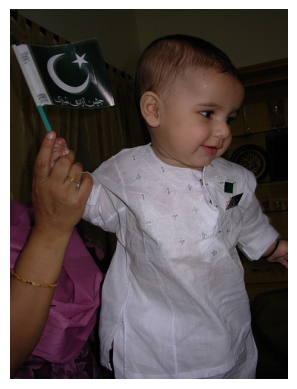

In [14]:
random_key = random.choice(list(mapping.keys()))

print("Image ID:", random_key)
print("Original Captions:")

for c in mapping[random_key]:
    print(c)

print("Feature Shape:", features[random_key].shape)

# Get embedding correctly
embedding = features[random_key][0]

print("Embedding Shape:", embedding.shape)
print("\nFirst 20 values:\n")
print(embedding[:20])

# Show image
img_path = os.path.join(IMAGE_FOLDER, random_key + ".jpg")
img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

## 6. Train test

In [15]:
image_ids = list(mapping.keys())
split = int(len(image_ids) * 0.85)

train = image_ids[:split]
test = image_ids[split:]

print("Train:", len(train))
print("Test:", len(test))

Train: 6877
Test: 1214


## 7. data generator

In [16]:
'''
def data_generator(data_keys, mapping, features,
                   tokenizer, max_length, vocab_size, batch_size):

    while True:
        X1, X2, y = [], [], []

        for key in data_keys:
            captions = mapping[key]

            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]

                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]

                    in_seq = pad_sequences([in_seq],
                                           maxlen=max_length)[0]

                    out_seq = to_categorical([out_seq],
                                             num_classes=vocab_size)[0]

                    X1.append(features[key][0])
                    X2.append(in_seq)
                    y.append(out_seq)

                    if len(X1) == batch_size:
                        yield [np.array(X1),
                               np.array(X2)], np.array(y)
                        X1, X2, y = [], [], []
                        '''

'\ndef data_generator(data_keys, mapping, features,\n                   tokenizer, max_length, vocab_size, batch_size):\n\n    while True:\n        X1, X2, y = [], [], []\n\n        for key in data_keys:\n            captions = mapping[key]\n\n            for caption in captions:\n                seq = tokenizer.texts_to_sequences([caption])[0]\n\n                for i in range(1, len(seq)):\n                    in_seq, out_seq = seq[:i], seq[i]\n\n                    in_seq = pad_sequences([in_seq],\n                                           maxlen=max_length)[0]\n\n                    out_seq = to_categorical([out_seq],\n                                             num_classes=vocab_size)[0]\n\n                    X1.append(features[key][0])\n                    X2.append(in_seq)\n                    y.append(out_seq)\n\n                    if len(X1) == batch_size:\n                        yield [np.array(X1),\n                               np.array(X2)], np.array(y)\n            

In [17]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Data generator function
def data_generator(data_keys, image_to_captions_mapping, features, tokenizer, max_caption_length, vocab_size, batch_size):

    # Lists to store batch data
    X1_batch, X2_batch, y_batch = [], [], []

    # Counter for batch size
    batch_count = 0

    while True:

        # Shuffle images every epoch (improves training)
        np.random.shuffle(data_keys)

        # Loop through each image
        for image_id in data_keys:

            # Skip if features missing
            if image_id not in features:
                continue

            captions = image_to_captions_mapping[image_id]

            # Loop through captions
            for caption in captions:

                # Convert caption to token sequence
                caption_seq = tokenizer.texts_to_sequences([caption])[0]

                # Create input-output pairs
                for i in range(1, len(caption_seq)):

                    in_seq = caption_seq[:i]
                    out_seq = caption_seq[i]

                    # Pad input sequence
                    in_seq = pad_sequences([in_seq], maxlen=max_caption_length)[0]

                    # Append to batch
                    X1_batch.append(features[image_id][0])   # Image features
                    X2_batch.append(in_seq)                  # Caption input
                    y_batch.append(out_seq)                  # Target word (integer)

                    batch_count += 1

                    # When batch is full
                    if batch_count == batch_size:

                        X1_batch = np.array(X1_batch)
                        X2_batch = np.array(X2_batch)
                        y_batch = np.array(y_batch)

                        yield [X1_batch, X2_batch], y_batch

                        # Reset batch
                        X1_batch, X2_batch, y_batch = [], [], []
                        batch_count = 0

## 8. Model Creation

In [ ]:
'''# Image branch
from tensorflow.keras.optimizers import Adam

inputs1 = Input(shape=(4096,))
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# Text branch ----------- LSTM
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.4)(se1)
se3 = LSTM(256)(se2)

# Decoder
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2],
              outputs=outputs)

model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

model.summary()'''

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 37)]         0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 4096)]       0           []                               
                                                                                                  
 embedding (Embedding)          (None, 37, 256)      2247936     ['input_3[0][0]']                
                                                                                                  
 dropout (Dropout)              (None, 4096)         0           ['input_2[0][0]']                
                                                                                            

In [19]:

# IMAGE FEATURE ENCODER

inputs1 = Input(shape=(4096,), name="image_features")

fe1 = Dropout(0.5)(inputs1)

fe2 = Dense(256, activation='relu')(fe1)

# Repeat image feature across caption length
fe2_repeat = RepeatVector(max_length)(fe2)

fe2_lstm = Bidirectional(
    LSTM(256, return_sequences=True)
)(fe2_repeat)



NameError: name 'RepeatVector' is not defined

In [114]:
# TEXT SEQUENCE ENCODER


inputs2 = Input(shape=(max_length,), name="caption_sequence")

se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)

se2 = Dropout(0.5)(se1)

se3 = Bidirectional(
    LSTM(256, return_sequences=True)
)(se2)

#

In [115]:
# ATTENTION MECHANISM


attention = Dot(axes=[2,2])([fe2_lstm, se3])

attention_weights = Activation('softmax')(attention)

attention_context = Lambda(
    lambda x: tf.einsum('ijk,ijl->ikl', x[0], x[1])
)([attention_weights, se3])

context_vector = Lambda(
    lambda x: tf.reduce_sum(x, axis=1)
)(attention_context)



In [116]:
 
# DECODER


decoder_input = concatenate([context_vector, fe2])

decoder1 = Dense(256, activation='relu')(decoder_input)

outputs = Dense(vocab_size, activation='softmax')(decoder1)



In [117]:

# BUILD MODEL

model = Model(inputs=[inputs1, inputs2], outputs=outputs)

optimizer = Adam(learning_rate=0.0001)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)



In [118]:
# SUMMARY

model.summary()


Model: "model_12"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_features (InputLayer)    [(None, 4096)]       0           []                               
                                                                                                  
 dropout_15 (Dropout)           (None, 4096)         0           ['image_features[0][0]']         
                                                                                                  
 caption_sequence (InputLayer)  [(None, 37)]         0           []                               
                                                                                                  
 dense_21 (Dense)               (None, 256)          1048832     ['dropout_15[0][0]']             
                                                                                           

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_features (InputLayer)    [(None, 4096)]       0           []                               
                                                                                                  
 dropout_4 (Dropout)            (None, 4096)         0           ['image_features[0][0]']         
                                                                                                  
 caption_sequence (InputLayer)  [(None, 37)]         0           []                               
                                                                                                  
 dense_5 (Dense)                (None, 256)          1048832     ['dropout_4[0][0]']              
                                                                                            

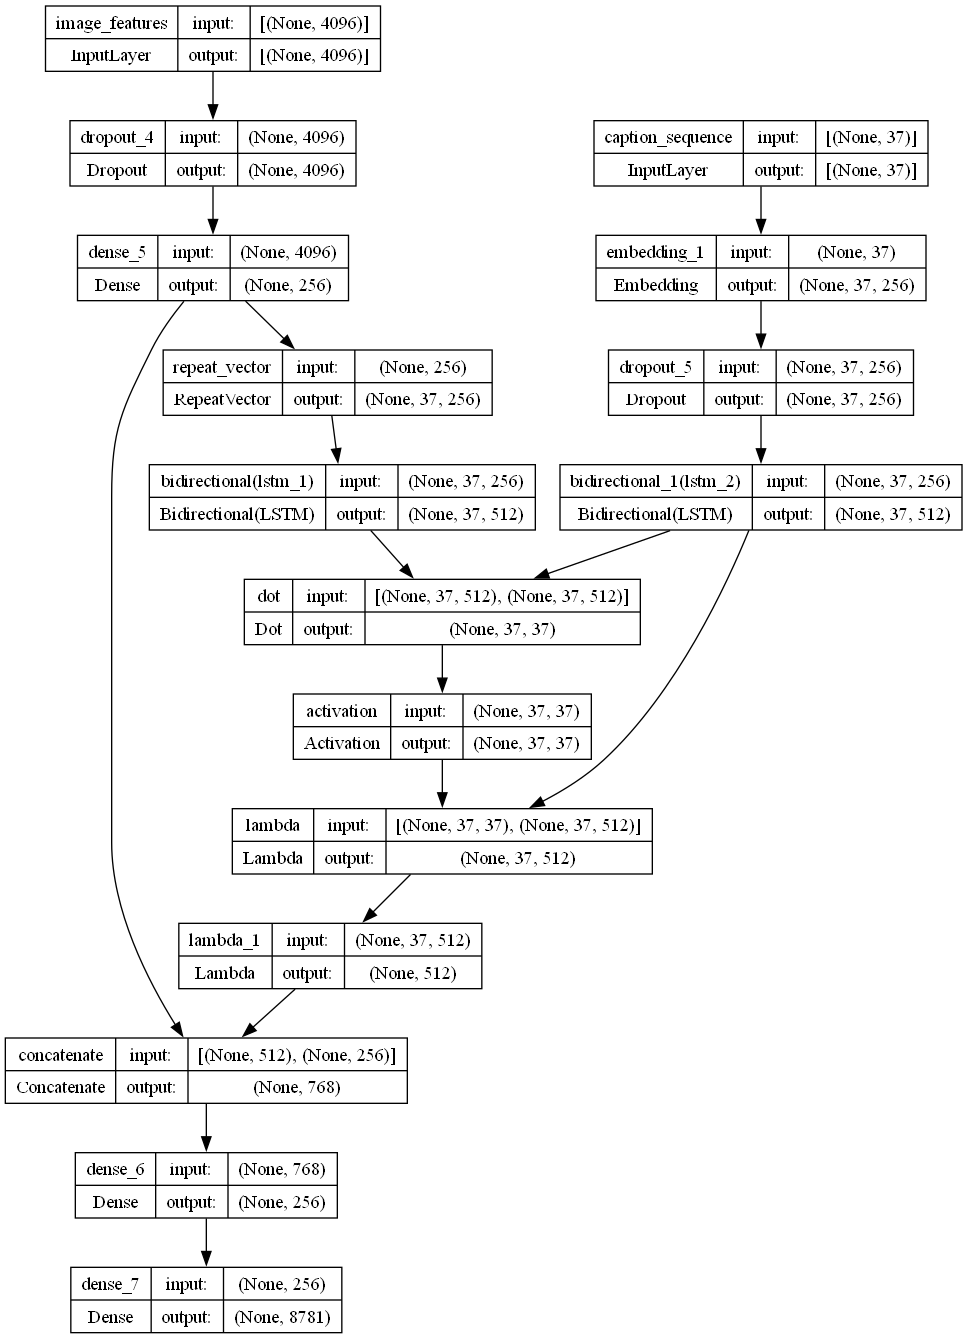

In [21]:
# ------------------------------------------------------------
# REQUIRED IMPORTS (MISSING IN YOUR CODE)
# ------------------------------------------------------------

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, LSTM, Embedding, Dropout,
    RepeatVector, Bidirectional,
    Dot, Activation, Lambda, concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model


# ------------------------------------------------------------
# IMAGE FEATURE ENCODER
# ------------------------------------------------------------

inputs1 = Input(shape=(4096,), name="image_features")

fe1 = Dropout(0.5)(inputs1)

fe2 = Dense(256, activation='relu')(fe1)

# Repeat image feature across caption length
fe2_repeat = RepeatVector(max_length)(fe2)

fe2_lstm = Bidirectional(
    LSTM(256, return_sequences=True)
)(fe2_repeat)


# ------------------------------------------------------------
# TEXT SEQUENCE ENCODER
# ------------------------------------------------------------

inputs2 = Input(shape=(max_length,), name="caption_sequence")

se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)

se2 = Dropout(0.5)(se1)

se3 = Bidirectional(
    LSTM(256, return_sequences=True)
)(se2)


# ------------------------------------------------------------
# ATTENTION MECHANISM
# ------------------------------------------------------------

# similarity between image sequence and text sequence
attention = Dot(axes=-1)([fe2_lstm, se3])

attention_weights = Activation('softmax')(attention)

# context vector
attention_context = Lambda(
    lambda x: tf.matmul(x[0], x[1])
)([attention_weights, se3])

# final context representation
context_vector = Lambda(
    lambda x: tf.reduce_sum(x, axis=1)
)(attention_context)


# ------------------------------------------------------------
# DECODER
# ------------------------------------------------------------

decoder_input = concatenate([context_vector, fe2])

decoder1 = Dense(256, activation='relu')(decoder_input)

outputs = Dense(vocab_size, activation='softmax')(decoder1)


# ------------------------------------------------------------
# BUILD MODEL
# ------------------------------------------------------------

model = Model(inputs=[inputs1, inputs2], outputs=outputs)

optimizer = Adam(learning_rate=0.0001)

# IMPORTANT FIX:
# Your generator outputs integer labels, not one-hot vectors
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

model.summary()

plot_model(model, show_shapes=True)

## 9. Model traing 50 epos

In [ ]:
from math import ceil

# =============================
# TRAIN SETTINGS
# =============================

epochs = 50
batch_size = 32

# IMPORTANT:
# Each image produces many caption sequences
# so steps should be based on number of images

steps_per_epoch = max(1, len(train) // batch_size)
validation_steps = max(1, len(test) // batch_size)

# =============================
# CREATE GENERATORS (ONCE)
# =============================

train_generator = data_generator(
    train,
    mapping,
    features,
    tokenizer,
    max_length,
    vocab_size,
    batch_size
)

val_generator = data_generator(
    test,
    mapping,
    features,
    tokenizer,
    max_length,
    vocab_size,
    batch_size
)

# =============================
# TRAIN MODEL
# =============================

history = model.fit(
    train_generator,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    verbose=1
)

# =============================
# SAVE MODEL
# =============================

model.save("cnn_lstm_caption_model_final.h5")

print(" Model saved successfully")

Epoch 1/50
214/214 [==============================] - 273s 1s/step - loss: 5.8710 - accuracy: 0.1567 - val_loss: 5.6371 - val_accuracy: 0.1774
Epoch 2/50
214/214 [==============================] - 253s 1s/step - loss: 5.6306 - accuracy: 0.1627 - val_loss: 5.2183 - val_accuracy: 0.1740
Epoch 3/50
214/214 [==============================] - 239s 1s/step - loss: 5.3515 - accuracy: 0.1754 - val_loss: 5.2758 - val_accuracy: 0.1875
Epoch 4/50
214/214 [==============================] - 238s 1s/step - loss: 5.1957 - accuracy: 0.1860 - val_loss: 5.1708 - val_accuracy: 0.1791
Epoch 5/50
214/214 [==============================] - 311s 1s/step - loss: 5.0538 - accuracy: 0.2091 - val_loss: 5.0239 - val_accuracy: 0.2027
Epoch 6/50
214/214 [==============================] - 278s 1s/step - loss: 4.9298 - accuracy: 0.2323 - val_loss: 4.9367 - val_accuracy: 0.2188
Epoch 7/50
214/214 [==============================] - 280s 1s/step - loss: 4.7328 - accuracy: 0.2399 - val_loss: 4.3890 - val_accuracy: 0.2551

## 10. Accuracy plot

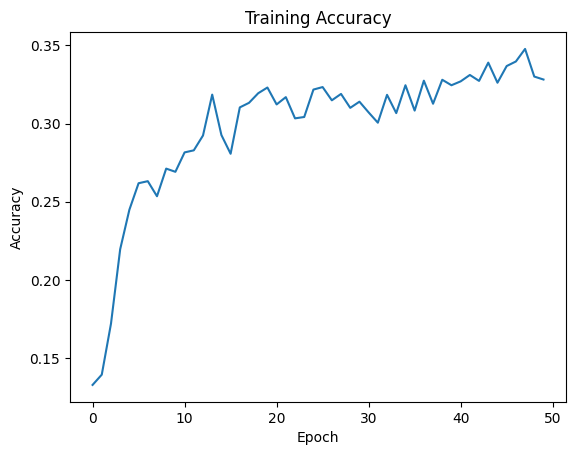

In [ ]:


plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

## 11. prediction

In [ ]:

# ==============================

import tensorflow as tf
import numpy as np
import pickle
import matplotlib.pyplot as plt

from PIL import Image
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences


# ==============================
# 2️ GPU MEMORY SAFE SETUP
# ==============================

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        print(" GPU memory growth enabled")

    except RuntimeError as e:
        print(e)


# ==============================
# 3️ FILE PATHS
# ==============================

MODEL_PATH = r"H:/4. Projects_envs/9. Image caption tf/cnn_lstm_image_caption_model.h5"
TOKENIZER_PATH = r"H:/4. Projects_envs/9. Image caption tf/Caption_vocab_tf.pkl"

TEST_IMAGE = r"H:/4. Projects_envs/9. Image caption tf/Tobby 1.jpg"


# ==============================
# 4️ LOAD TRAINED MODEL
# ==============================

print("Loading caption model...")

model = load_model(MODEL_PATH, compile=False)

print(" Caption model loaded")


# ==============================
# 5️ LOAD TOKENIZER
# ==============================

with open(TOKENIZER_PATH, "rb") as f:
    tokenizer = pickle.load(f)

print(" Tokenizer loaded")

index_word = tokenizer.index_word


# ==============================
# 6️ GET MAX CAPTION LENGTH
# ==============================

max_length = model.input[1].shape[1]

print("Max caption length:", max_length)


# ==============================
# 7️ LOAD VGG16 FEATURE EXTRACTOR
# ==============================

print("Loading VGG16...")

base_model = VGG16(weights="imagenet")

vgg_model = Model(
    inputs=base_model.inputs,
    outputs=base_model.layers[-2].output
)

print(" VGG16 loaded (4096-dim features)")


# ==============================
# 8️ CAPTION GENERATION FUNCTION
# ==============================

def predict_caption(image_feature):

    in_text = "startseq"

    for i in range(max_length):

        sequence = tokenizer.texts_to_sequences([in_text])[0]

        sequence = pad_sequences([sequence], maxlen=max_length)

        yhat = model.predict([image_feature, sequence], verbose=0)

        yhat = np.argmax(yhat, axis=-1)[0]

        word = index_word.get(yhat)

        if word is None:
            break

        in_text += " " + word

        if word == "endseq":
            break

    final_caption = in_text.replace("startseq", "").replace("endseq", "").strip()

    return final_caption


# ==============================
# 9️ IMAGE → FEATURE FUNCTION
# ==============================

def extract_features(image_path):

    img = load_img(image_path, target_size=(224,224))

    img = img_to_array(img)

    img = np.expand_dims(img, axis=0)

    img = preprocess_input(img)

    feature = vgg_model.predict(img, verbose=0)

    return feature


# ==============================
#  MAIN CAPTION FUNCTION
# ==============================

def generate_caption(image_path):

    image = Image.open(image_path)

    feature = extract_features(image_path)

    caption = predict_caption(feature)

    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(caption)

    plt.show()

    print("\nPredicted Caption:")
    print(caption)


# ==============================
#  RUN PREDICTION
# ==============================

generate_caption(TEST_IMAGE)

## model with 100 epocks

In [68]:
# ==============================
# TRAIN / VALIDATION SPLIT
# ==============================

from sklearn.model_selection import train_test_split

# All image IDs
image_ids = list(mapping.keys())

# 80% train, 20% validation
train, val = train_test_split(
    image_ids,
    test_size=0.2,
    random_state=42
)

print("Train images:", len(train))
print("Validation images:", len(val))

Train images: 6472
Validation images: 1619


Starting Training...
Epoch 1/100
202/202 [==============================] - 124s 551ms/step - loss: 3.8859 - accuracy: 0.3752 - val_loss: 4.2777 - val_accuracy: 0.3713 - lr: 1.0000e-04
Epoch 2/100
202/202 [==============================] - 107s 530ms/step - loss: 4.0356 - accuracy: 0.3676 - val_loss: 4.4903 - val_accuracy: 0.3363 - lr: 1.0000e-04
Epoch 3/100
202/202 [==============================] - 109s 542ms/step - loss: 4.1509 - accuracy: 0.3639 - val_loss: 4.3520 - val_accuracy: 0.3531 - lr: 1.0000e-04
Epoch 4/100
202/202 [==============================] - 108s 537ms/step - loss: 4.1614 - accuracy: 0.3586 - val_loss: 4.2057 - val_accuracy: 0.3956 - lr: 1.0000e-04
Epoch 5/100
202/202 [==============================] - 109s 540ms/step - loss: 4.2083 - accuracy: 0.3603 - val_loss: 5.1139 - val_accuracy: 0.3413 - lr: 1.0000e-04
Epoch 6/100
202/202 [==============================] - 108s 537ms/step - loss: 4.1803 - accuracy: 0.3680 - val_loss: 4.3827 - val_accuracy: 0.3631 - lr: 1.0000

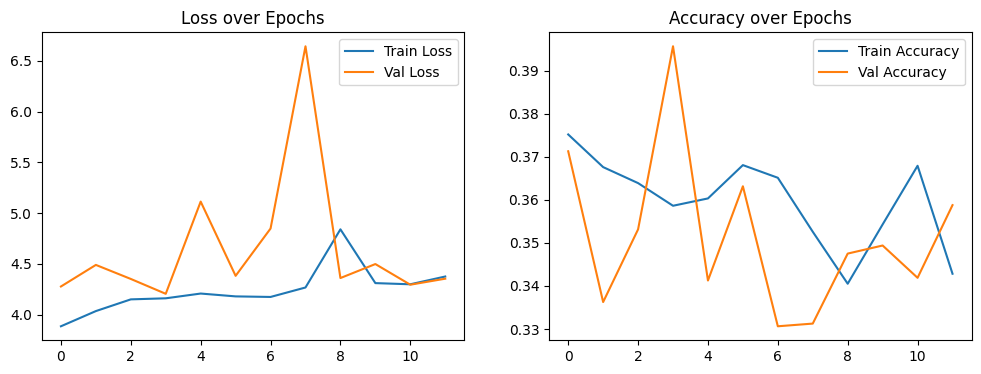

In [79]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
import matplotlib.pyplot as plt

# ==============================
# TRAIN SETTINGS
# ==============================
epochs = 100 
batch_size = 32 # 32 generalizes better than 64 for Flickr8k

steps = max(1, len(train) // batch_size)
val_steps = max(1, len(val) // batch_size)

# ==============================
# COMPILE MODEL
# ==============================
optimizer = Adam(learning_rate=0.0001) 

model.compile(
    loss=CategoricalCrossentropy(label_smoothing=0.1), # Label smoothing helps prevent overfitting
    optimizer=optimizer,
    metrics=['accuracy'] 
)

# ==============================
# CALLBACKS
# ==============================
# 1. Stop training when validation loss stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True, # <-- THIS IS CRUCIAL. It ensures the final saved model is the best one.
    verbose=1
)

# 2. Reduce Learning Rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5, 
    patience=3,
    verbose=1,
    min_lr=1e-7
)

# ==============================
# TRAIN MODEL
# ==============================
print("Starting Training...")
history = model.fit(
    data_generator(train, mapping, features, tokenizer, max_length, vocab_size, batch_size),
    epochs=epochs,
    steps_per_epoch=steps,
    validation_data=data_generator(val, mapping, features, tokenizer, max_length, vocab_size, batch_size),
    validation_steps=val_steps,
    callbacks=[early_stop, reduce_lr], # Removed ModelCheckpoint
    verbose=1
)

# ==============================
# SAVE FINAL (BEST) MODEL
# ==============================
# Because restore_best_weights=True is on, this saves the best model, not the last epoch.
model.save("best_flickr8k_model.h5")
print("Final Best Model Saved Successfully as 'best_flickr8k_model.h5'")

# ==============================
# PLOT RESULTS
# ==============================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.show()

In [ ]:
# ==============================
# PLOT LOSS
# ==============================

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# ==============================
# LOAD BEST MODEL FOR PREDICTION
# ==============================

from tensorflow.keras.models import load_model

model = load_model("cnn_lstm_caption_model_100epochs.h5")

# ==============================
# PREDICT FUNCTION
# ==============================

index_word = tokenizer.index_word

def predict_caption(image_feature):
    in_text = "startseq"

    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)

        yhat = model.predict([image_feature, sequence], verbose=0)
        yhat = yhat.argmax()

        word = index_word.get(yhat)
        if word is None:
            break

        in_text += " " + word

        if word == "endseq":
            break

    return in_text.replace("startseq", "").replace("endseq", "").strip()

In [ ]:
# ============================================================
# CNN + LSTM IMAGE CAPTION PREDICTION (100 EPOCH MODEL)
# ============================================================

# ==============================
# 0️ GPU MEMORY SAFE SETUP
# ==============================

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)

# ==============================
# IMPORT LIBRARIES
# ==============================

import numpy as np
import pickle
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ==============================
# SETTINGS (100 EPOCH MODEL)
# ==============================

MODEL_PATH = r"H:/4. Projects_envs/9. Image caption tf/cnn_lstm_caption_model_100epochs.h5"
TOKENIZER_PATH = r"H:/4. Projects_envs/9. Image caption tf/Caption_vocab_tf.pkl"

# ==============================
# LOAD MODEL & TOKENIZER
# ==============================

model = load_model(MODEL_PATH)

with open(TOKENIZER_PATH, "rb") as f:
    tokenizer = pickle.load(f)

print("✅ 100-Epoch Model & Tokenizer Loaded")

# Automatically get correct max_length
max_length = model.input[1].shape[1]
print("Correct max_length:", max_length)

index_word = tokenizer.index_word

# ==============================
# LOAD VGG16 (4096 FEATURE EXTRACTOR)
# ==============================

with tf.device('/CPU:0'):  # Prevent GPU OOM
    base_model = VGG16(weights="imagenet")
    vgg_model = Model(
        inputs=base_model.inputs,
        outputs=base_model.layers[-2].output
    )

print("✅ VGG16 Loaded")

# ==============================
# CAPTION GENERATOR
# ==============================

def predict_caption(image_feature):
    in_text = "startseq"

    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)

        yhat = model.predict([image_feature, sequence], verbose=0)
        yhat = np.argmax(yhat)

        word = index_word.get(yhat)
        if word is None:
            break

        in_text += " " + word

        if word == "endseq":
            break

    return in_text.replace("startseq", "").replace("endseq", "").strip()

# ==============================
# MAIN FUNCTION
# ==============================

def generate_caption_from_image(image_path):
    image = Image.open(image_path)

    img = load_img(image_path, target_size=(224, 224))
    img = img_to_array(img)
    img = img.reshape((1, 224, 224, 3))
    img = preprocess_input(img)

    with tf.device('/CPU:0'):
        feature = vgg_model.predict(img, verbose=0)

    caption = predict_caption(feature)

    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(caption, fontsize=12)
    plt.show()

    print("Predicted Caption:")
    print(caption)

# ==============================
# TEST
# ==============================

generate_caption_from_image(
    r"H:\4. Projects_envs\9. Image caption tf\Tobby 1.jpg"
)